# Futoshiki — Modelo de Constraint Programming (OR-Tools CP-SAT)

Lee los JSON del estado inicial (Fase 1) y resuelve cada tablero.

**Cómo usarlo:** pon en `JSONS` el link de Drive de `json.zip` (Colab) o la ruta al zip o a la carpeta (local) y ejecuta todo.

## 1. Configuración

In [ ]:
JSONS = 'https://drive.google.com/file/d/1W1Uecedl4N041kTDgP9v8H_oSLbGUPh0/view?usp=sharing'      # JSON del paso anterior -> Colab: link de Drive de json.zip | local: ruta al zip o a la carpeta

!pip install -q ortools gdown
import json, shutil, zipfile, gdown, time
import numpy as np, cv2, matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from ortools.sat.python import cp_model

if JSONS.startswith('http'):
    JSONS = gdown.download(JSONS, 'json.zip', fuzzy=True, quiet=True)
if JSONS.endswith('.zip'):
    shutil.rmtree('json_entrada', ignore_errors=True)
    zipfile.ZipFile(JSONS).extractall('json_entrada')
    JSONS = 'json_entrada'
ARCHIVOS = sorted(p for p in Path(JSONS).rglob('*.json') if '__MACOSX' not in p.parts)
print(len(ARCHIVOS), 'tableros')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 10.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
68 tableros


## 2. Modelo CP

| Elemento | Definición |
|---|---|
| **Variables** | $X_{i,j}$ para $i, j \in \{0, \dots, N-1\}$: el número de la celda $(i,j)$ |
| **Dominio** | $X_{i,j} \in \{1, \dots, N\}$ |
| **Restricción global** | $\text{AllDifferent}(X_{i,0}, \dots, X_{i,N-1})$ para cada fila $i$ |
| **Restricción global** | $\text{AllDifferent}(X_{0,j}, \dots, X_{N-1,j})$ para cada columna $j$ |
| **Pistas** | $X_{r,c} = v$ por cada dígito impreso |
| **Desigualdades (binarias)** | $X_{r_1,c_1} < X_{r_2,c_2}$ (o $>$) por cada signo |

El modelo es **parametrizado**: N, las pistas y los signos se leen del JSON; no hay nada fijo para un tablero en particular.

**Restricciones reificadas:** el modelo del acertijo no las necesita, porque todas sus reglas son incondicionales. Sí se usan para **verificar que la solución es única**: se prohíbe la solución encontrada con $b_{i,j} \Leftrightarrow X_{i,j} \neq s_{i,j}$ y $\bigvee b_{i,j}$, y se resuelve de nuevo. Si no hay otra solución, la lectura de la foto fue completa: si faltara un signo o un dígito, normalmente aparecería más de una solución.

In [ ]:
def resolver(estado, tiempo_max=10.0):
    """Modelo CP del Futoshiki, parametrizado por el JSON (sirve para cualquier N)."""
    N = estado['grid_size']
    m = cp_model.CpModel()

    # Variables y dominios: X[i][j] en {1..N}
    X = [[m.NewIntVar(1, N, f'X_{i}_{j}') for j in range(N)] for i in range(N)]

    # Restricciones globales: cuadrado latino
    for i in range(N):
        m.AddAllDifferent(X[i])                              # fila i
        m.AddAllDifferent([X[r][i] for r in range(N)])       # columna i

    # Pistas iniciales
    for d in estado['initial_digits']:
        m.Add(X[d['row']][d['col']] == d['value'])

    # Desigualdades (restricciones binarias)
    for q in estado['inequalities']:
        a, b = X[q['row1']][q['col1']], X[q['row2']][q['col2']]
        m.Add(a < b) if q['type'] == '<' else m.Add(a > b)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = tiempo_max
    t0 = time.perf_counter()
    status = solver.Solve(m)
    ms = (time.perf_counter() - t0) * 1000
    res = {'estado': solver.StatusName(status), 'solucion': None, 'unica': None, 'ms': round(ms, 2),
           'ramas': solver.NumBranches(), 'conflictos': solver.NumConflicts()}
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return res
    sol = [[solver.Value(X[i][j]) for j in range(N)] for i in range(N)]
    res['solucion'] = sol

    # Unicidad: se prohibe la solucion encontrada y se vuelve a resolver.
    # "Alguna celda distinta" se expresa con restricciones REIFICADAS: b_ij <=> X_ij != sol_ij
    distintas = []
    for i in range(N):
        for j in range(N):
            b = m.NewBoolVar(f'b_{i}_{j}')
            m.Add(X[i][j] != sol[i][j]).OnlyEnforceIf(b)
            m.Add(X[i][j] == sol[i][j]).OnlyEnforceIf(b.Not())
            distintas.append(b)
    m.AddBoolOr(distintas)
    res['unica'] = cp_model.CpSolver().Solve(m) == cp_model.INFEASIBLE
    return res


def es_valida(estado, sol):
    """Verificacion independiente del solver: cuadrado latino + pistas + desigualdades."""
    N = estado['grid_size']
    filas = all(sorted(f) == list(range(1, N + 1)) for f in sol)
    columnas = all(sorted(sol[r][c] for r in range(N)) == list(range(1, N + 1)) for c in range(N))
    pistas = all(sol[d['row']][d['col']] == d['value'] for d in estado['initial_digits'])
    desig = all((sol[q['row1']][q['col1']] < sol[q['row2']][q['col2']]) == (q['type'] == '<')
                for q in estado['inequalities'])
    return filas and columnas and pistas and desig

## 3. Dibujo de la solución
Pistas en negro y números encontrados por el solver en azul.

In [ ]:
def dibujar_solucion(estado, sol, tam=420):
    """Pistas en negro, numeros encontrados por el solver en azul."""
    N = estado['grid_size']
    img = np.full((tam, tam, 3), 255, np.uint8)
    lado = (tam - 40) / (N + (N - 1) * .4); sep = lado * .4
    pos = lambda i: 20 + i * (lado + sep)
    texto = lambda s, x, y, f, col: cv2.putText(img, s, (int(x - 9 * f), int(y + 9 * f)), cv2.FONT_HERSHEY_SIMPLEX, f, col, 2)
    pistas = {(d['row'], d['col']) for d in estado['initial_digits']}
    for r in range(N):
        for c in range(N):
            cv2.rectangle(img, (int(pos(c)), int(pos(r))), (int(pos(c) + lado), int(pos(r) + lado)), (0, 0, 0), 2)
            if sol:
                texto(str(sol[r][c]), pos(c) + lado / 2, pos(r) + lado / 2, lado / 40,
                      (0, 0, 0) if (r, c) in pistas else (200, 90, 0))
    for q in estado['inequalities']:
        if q['row1'] == q['row2']:
            texto(q['type'], pos(q['col1']) + lado + sep / 2, pos(q['row1']) + lado / 2, sep / 30, (0, 0, 0))
        else:
            texto('^' if q['type'] == '<' else 'v', pos(q['col1']) + lado / 2, pos(q['row1']) + lado + sep / 2, sep / 30, (0, 0, 0))
    return img

## 4. Resolver todos los tableros

- **OPTIMAL**: se encontró la solución.
- **INFEASIBLE**: no existe solución con lo que se leyó; hay un error en la lectura de la foto.
- **unica = False**: hay más de una solución; probablemente faltó leer algún signo o dígito.
- **verificada**: la solución se comprobó con un código independiente del solver.

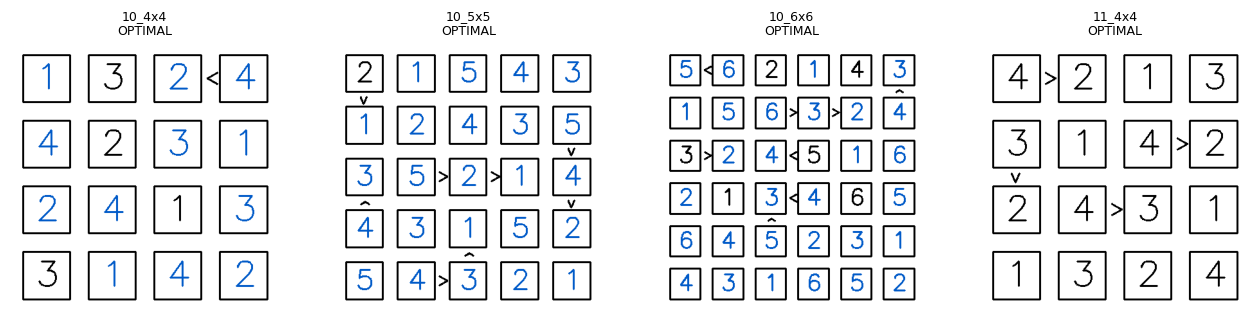

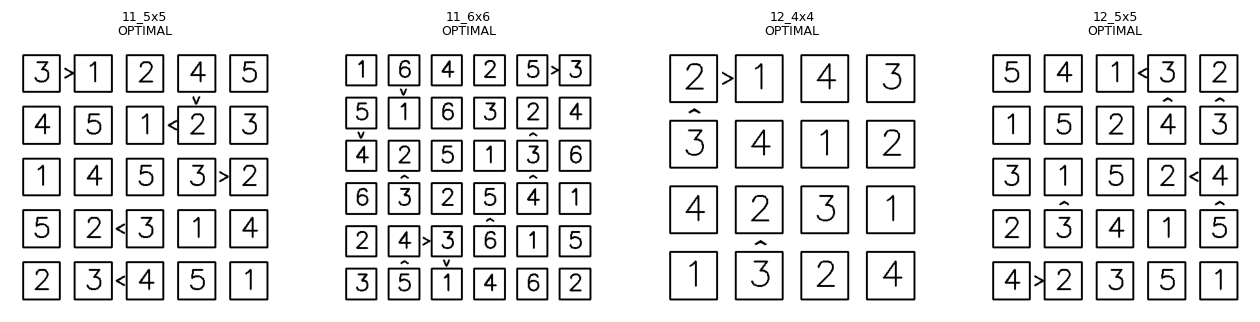

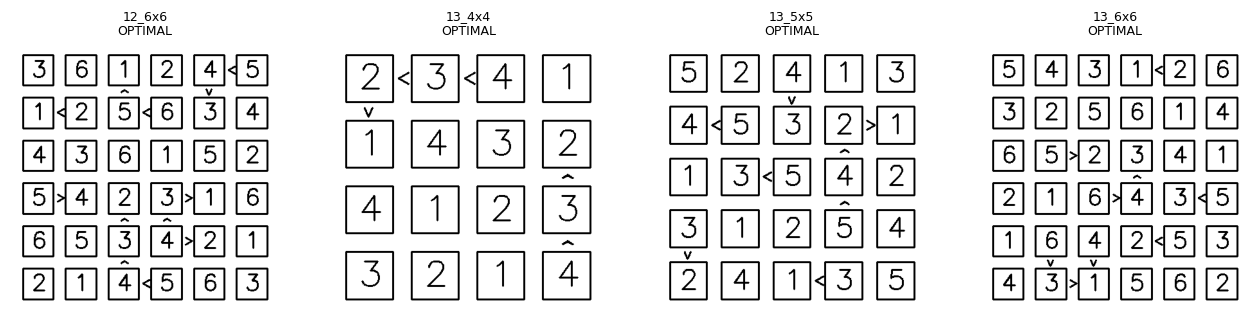

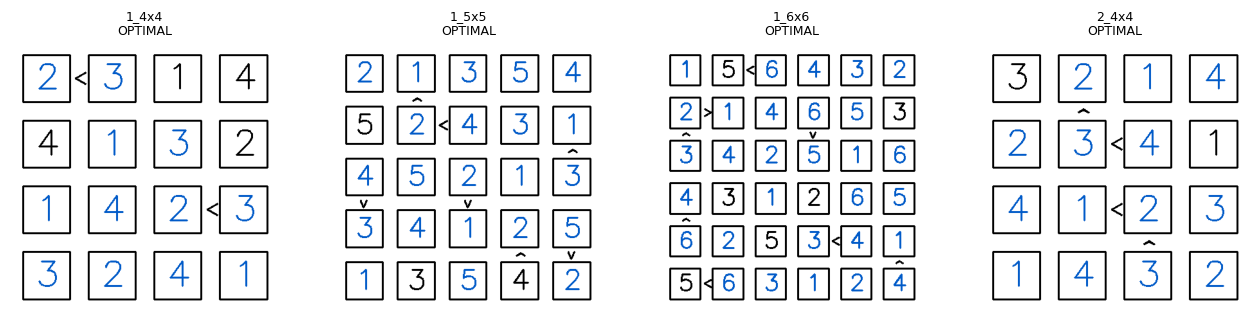

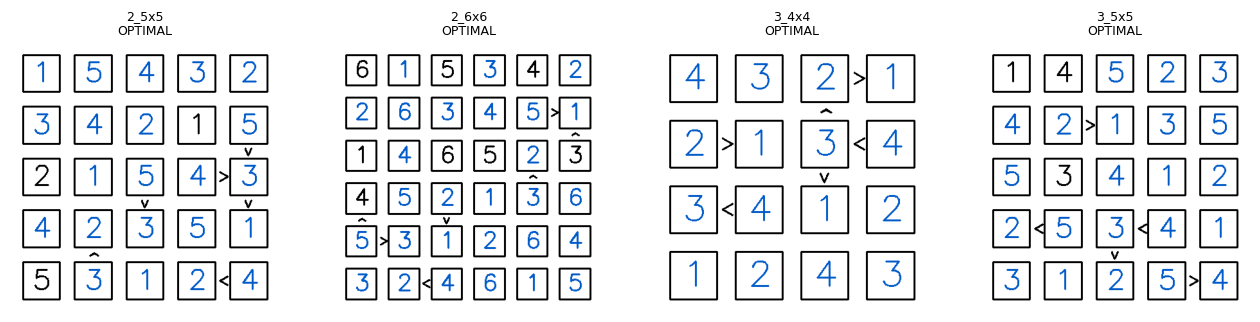

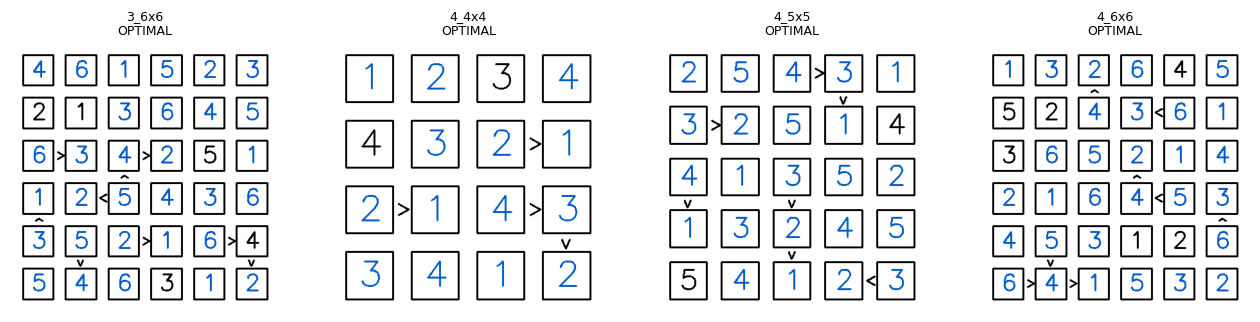

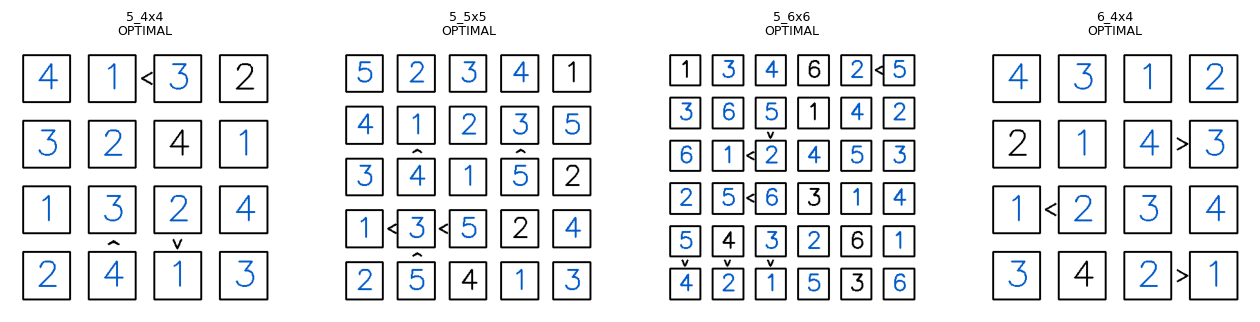

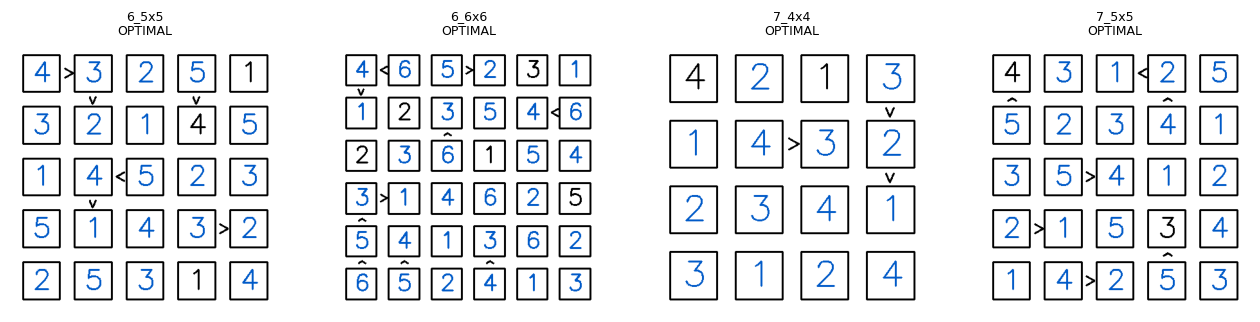

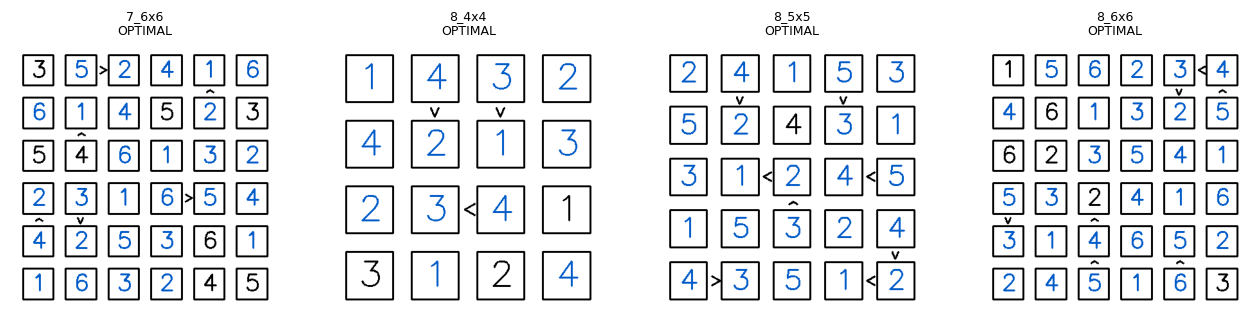

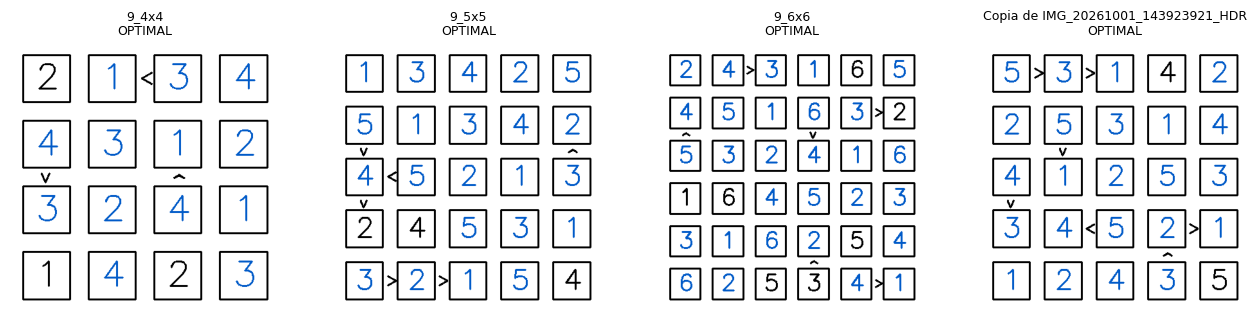

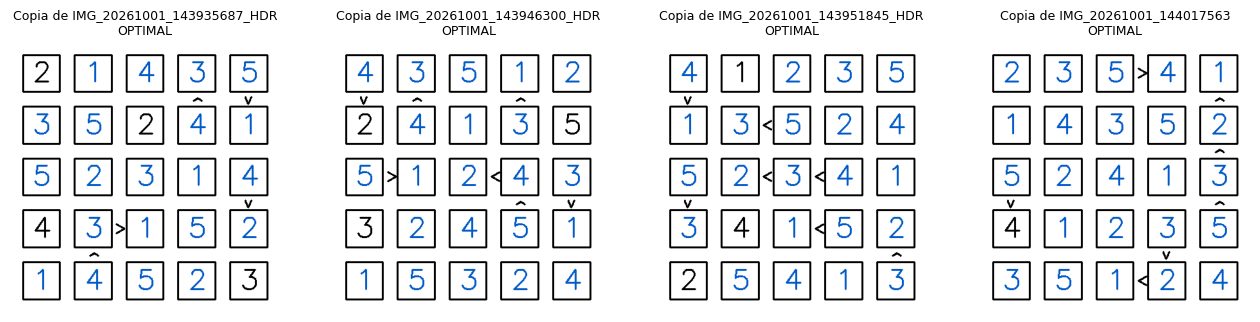

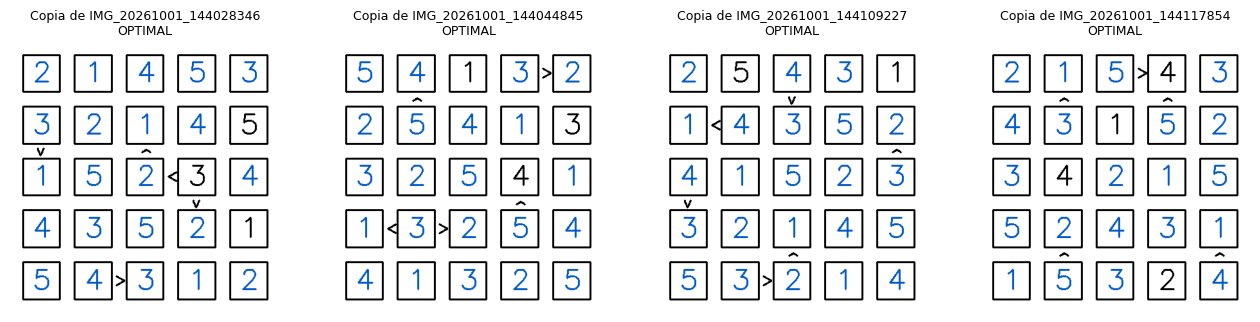

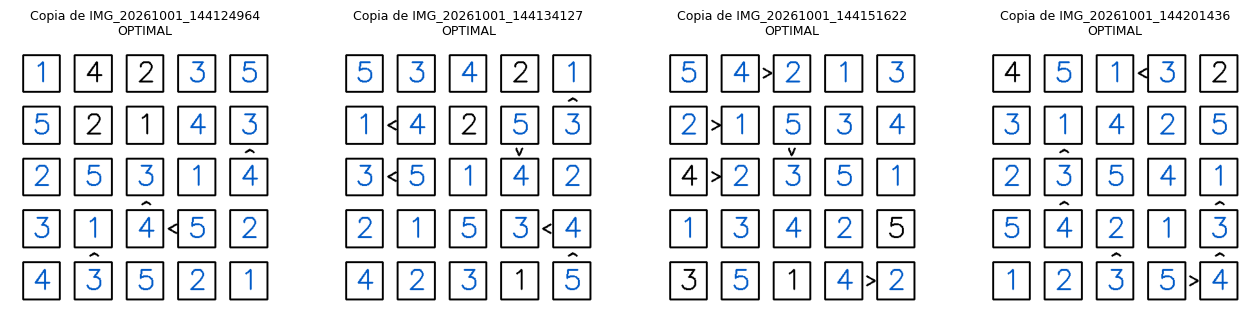

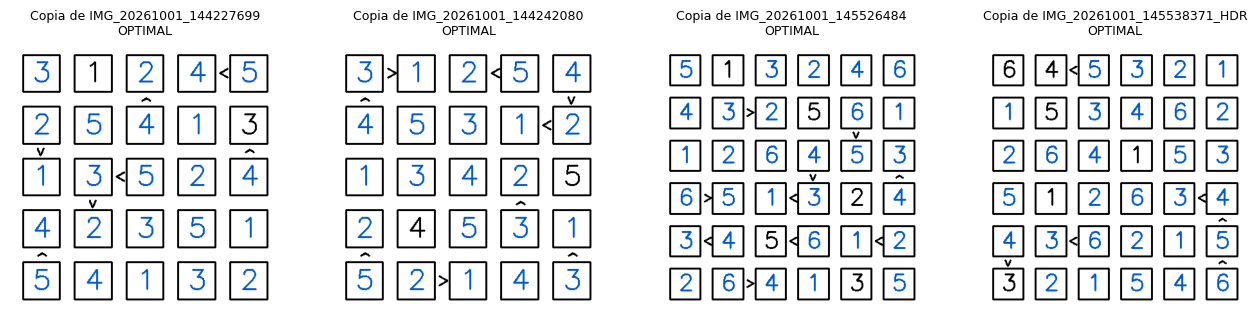

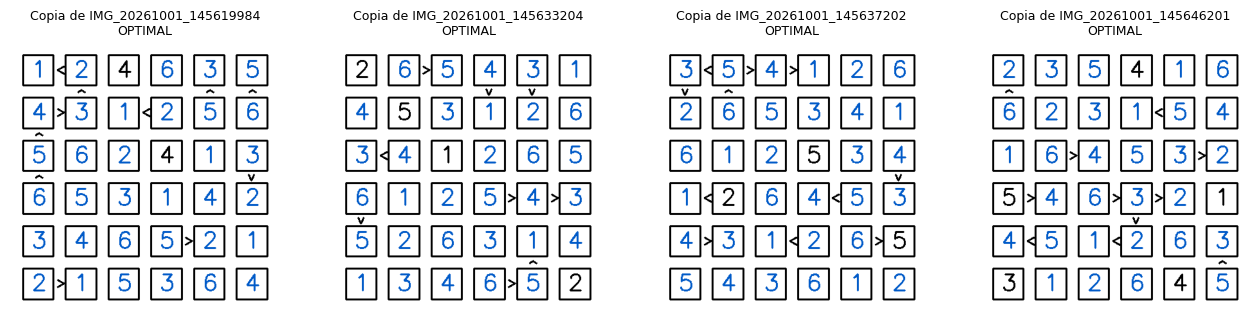

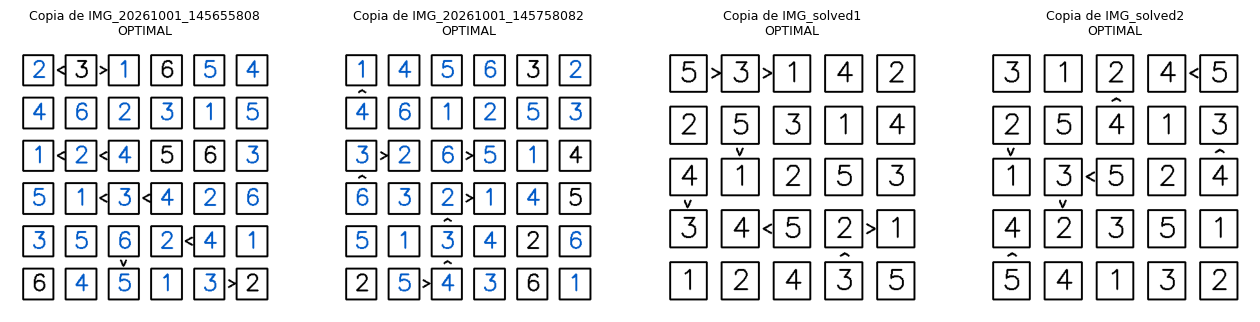

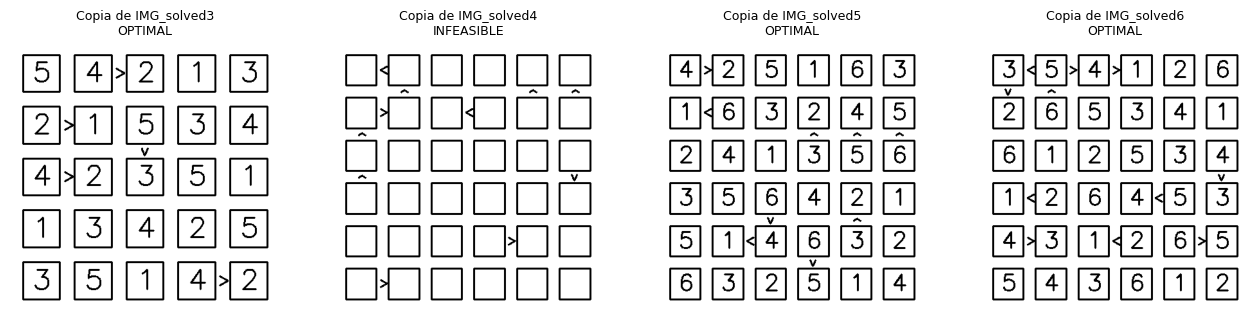

,tablero,N,pistas,signos,estado,unica,verificada,ms,ramas,conflictos
0,10_4x4,4,4,1,OPTIMAL,True,True,8.90,0,0
1,10_5x5,5,1,8,OPTIMAL,True,True,1.92,0,0
2,10_6x6,6,6,8,OPTIMAL,True,True,3.19,0,0
3,11_4x4,4,16,4,OPTIMAL,True,True,2.63,0,0
4,11_5x5,5,25,6,OPTIMAL,True,True,2.68,0,0
...,...,...,...,...,...,...,...,...,...,...
63,Copia de IMG_solved2,5,25,7,OPTIMAL,True,True,2.38,0,0
64,Copia de IMG_solved3,5,25,5,OPTIMAL,True,True,1.25,0,0
65,Copia de IMG_solved4,6,36,11,INFEASIBLE,None,False,0.21,0,0
66,Copia de IMG_solved5,6,36,9,OPTIMAL,True,True,2.98,0,0



Sin solucion (revisar la lectura de la foto): ['Copia de IMG_solved4']
Con mas de una solucion (probablemente falto leer un signo o digito): []

Tiempo del solver por tamano (para el informe):


ms       ramas     conflictos    
   mean   max  mean max       mean max
N                                     
4  3.04  8.90   0.0   0        0.0   0
5  2.74  6.64   0.0   0        0.0   0
6  2.95  4.91   0.0   0        0.0   0

In [ ]:
Path('soluciones').mkdir(exist_ok=True)
filas, imgs, titulos = [], [], []
for ruta in ARCHIVOS:
    estado = json.loads(ruta.read_text())
    r = resolver(estado)
    valida = r['solucion'] is not None and es_valida(estado, r['solucion'])
    filas.append({'tablero': ruta.stem, 'N': estado['grid_size'], 'pistas': len(estado['initial_digits']),
                  'signos': len(estado['inequalities']), 'estado': r['estado'], 'unica': r['unica'],
                  'verificada': valida, 'ms': r['ms'], 'ramas': r['ramas'], 'conflictos': r['conflictos']})
    Path('soluciones', ruta.name).write_text(json.dumps({**estado, 'solution': r['solucion']}, indent=2))
    imgs.append(dibujar_solucion(estado, r['solucion']))
    titulos.append(f"{ruta.stem}\n{r['estado']}" + ('' if r['unica'] in (None, True) else ' (NO UNICA)'))

for k in range(0, len(imgs), 4):                       # 4 tableros por fila
    fig, ejes = plt.subplots(1, 4, figsize=(16, 4.4))
    for ax in ejes: ax.axis('off')
    for ax, im, t in zip(ejes, imgs[k:k + 4], titulos[k:k + 4]):
        ax.imshow(im[..., ::-1]); ax.set_title(t, fontsize=9)
    plt.show()

tabla = pd.DataFrame(filas)
display(tabla)
print('\nSin solucion (revisar la lectura de la foto):', list(tabla[tabla.estado == 'INFEASIBLE'].tablero))
print('Con mas de una solucion (probablemente falto leer un signo o digito):', list(tabla[tabla.unica == False].tablero))
print('\nTiempo del solver por tamano (para el informe):')
display(tabla.groupby('N')[['ms', 'ramas', 'conflictos']].agg(['mean', 'max']).round(2))

## 5. Descargar las soluciones

In [ ]:
shutil.make_archive('soluciones', 'zip', 'soluciones')
try:                                                   # Colab: descarga | local: ya estan en la carpeta
    from google.colab import files
    files.download('soluciones.zip')
except ImportError:
    print('Soluciones en', Path('soluciones').resolve())